# Phase 2 — Phase simulation validation

Runs a full 8-phase match between two rosters and checks:
- mean performance tracks composite over many runs
- low-awareness players swing harder in self-evaluation
- late-game performance erodes for low-stamina rosters

No Ren'Py. Pure engine. Reproducible via seeded `numpy.random.Generator`.

In [1]:
import sys, pathlib
# Notebook runs from notebooks/ — add game/ to path for engine imports.
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'game'))

import numpy as np
import matplotlib.pyplot as plt

from engine.characters import CharacterRole, TierACharacter, TierBCharacter
from engine.simulation import (
    MAX_PHASES_DEFAULT,
    Sport,
    fatigue_factor,
    self_evaluate,
    simulate_phase,
    stat_composite,
    team_morale_delta,
)
from engine.stats import StatName, StatTuple

## Roster builders
Tier A for our team (so self-eval works), Tier B for opponents.

In [2]:
def build_player(id_, role, **overrides):
    """Build a Tier A player with sensible defaults, letting callers override per-stat values."""
    defaults = {s: 0.5 for s in StatName}
    defaults.update(overrides)
    stats = {
        s: StatTuple(value=v, awareness=0.6, focus=0.4) for s, v in defaults.items()
    }
    return TierACharacter(id=id_, name=id_, role=role, stats=stats)


def build_opponent(id_, skill=0.5):
    return TierBCharacter(
        id=id_,
        name=id_,
        role=CharacterRole.MIDFIELDER,
        stats={s: skill for s in StatName},
    )


home = [
    build_player('striker_1', CharacterRole.STRIKER, **{StatName.SPEED: 0.8, StatName.FINESSE: 0.7, StatName.CONFIDENCE: 0.7}),
    build_player('mid_1', CharacterRole.MIDFIELDER, **{StatName.STAMINA: 0.8, StatName.COLLABORATION: 0.7}),
    build_player('def_1', CharacterRole.DEFENDER, **{StatName.STRENGTH: 0.8, StatName.CAUTIOUSNESS: 0.7}),
    build_player('def_2', CharacterRole.DEFENDER, **{StatName.STRENGTH: 0.7, StatName.STAMINA: 0.6}),
]
away = [build_opponent(f'away_{i}', skill=0.55) for i in range(4)]

[stat_composite(p) for p in home], [stat_composite(o) for o in away]

([0.6499999999999999, 0.56, 0.56, 0.5599999999999999],
 [0.55, 0.55, 0.55, 0.55])

## A single match

In [3]:
rng = np.random.default_rng(2026)
momentum = 0.0
results = []
for phase in range(MAX_PHASES_DEFAULT):
    r = simulate_phase(home, away, phase, momentum, rng)
    momentum = r.momentum
    results.append(r)

goals = [r.phase_number for r in results if r.goal_scored]
print('goals scored in phases:', goals)
print('final momentum:', momentum)

goals scored in phases: []
final momentum: 0.1262227453713889


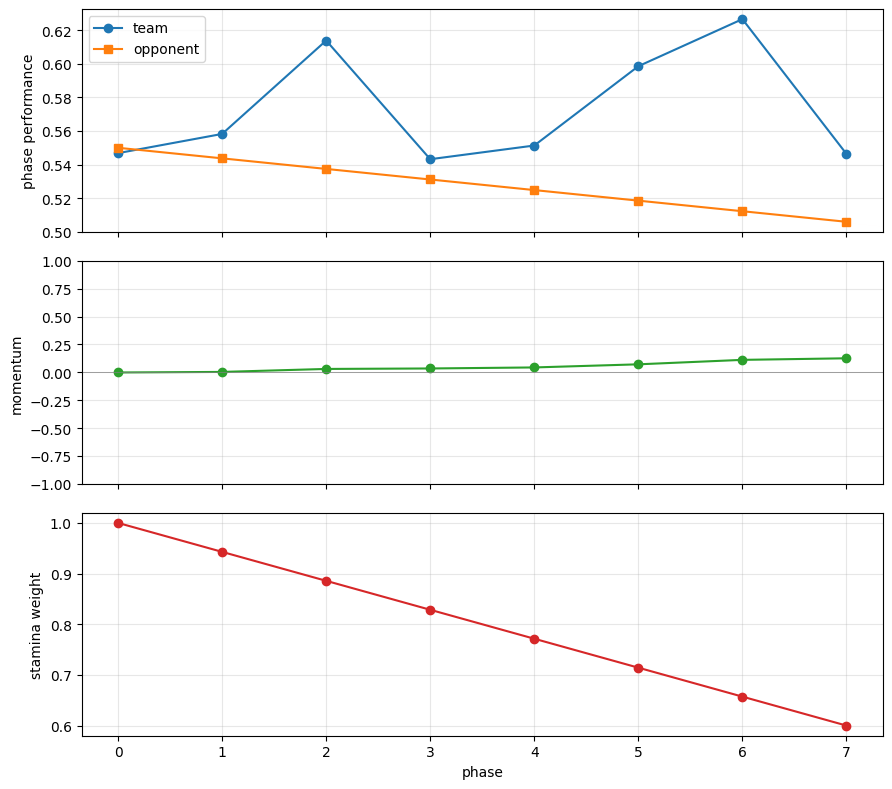

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
phases = [r.phase_number for r in results]

axes[0].plot(phases, [r.team_perf for r in results], 'o-', label='team')
axes[0].plot(phases, [r.opp_perf for r in results], 's-', label='opponent')
axes[0].set_ylabel('phase performance')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(phases, [r.momentum for r in results], 'o-', color='C2')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('momentum'); axes[1].set_ylim(-1, 1); axes[1].grid(alpha=0.3)

axes[2].plot(phases, [fatigue_factor(p, MAX_PHASES_DEFAULT) for p in phases], 'o-', color='C3')
axes[2].set_ylabel('stamina weight'); axes[2].set_xlabel('phase'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Validation 1 — mean performance ≈ composite
Repeat phase 0 many times; the team-mean performance should centre near the team's composite (pre-synergy).

expected composite mean: 0.583
empirical mean over 800 phase draws: 0.578


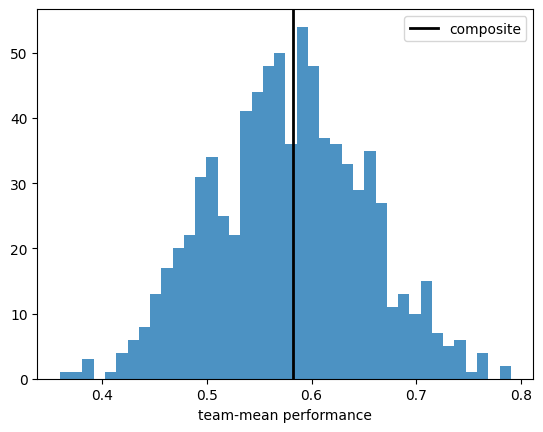

In [5]:
rng = np.random.default_rng(0)
n_trials = 800
team_means = []
for _ in range(n_trials):
    r = simulate_phase(home, away, 0, 0.0, rng)
    team_means.append(r.performances.mean())

expected = np.mean([stat_composite(p) for p in home])
empirical = np.mean(team_means)
print(f'expected composite mean: {expected:.3f}')
print(f'empirical mean over {n_trials} phase draws: {empirical:.3f}')
assert abs(empirical - expected) < 0.02, 'distribution drift'

plt.hist(team_means, bins=40, alpha=0.8); plt.axvline(expected, color='k', lw=2, label='composite')
plt.xlabel('team-mean performance'); plt.legend(); plt.show()

## Validation 2 — low awareness swings harder
Same actual performance; low-awareness self-reads have much wider variance.

aware   — mean 0.550, std 0.010
unaware — mean 0.543, std 0.177


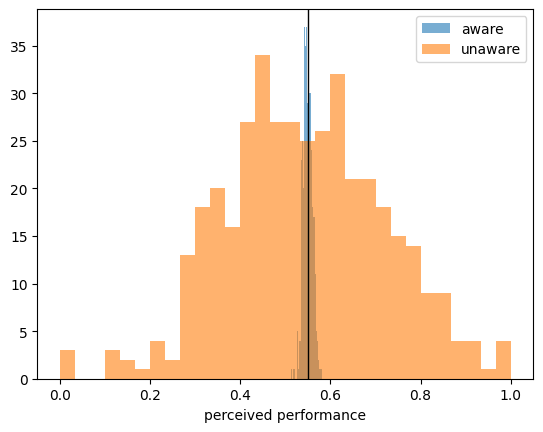

In [6]:
aware = build_player('aware', CharacterRole.STRIKER)
aware.stats[StatName.INTROSPECTION] = StatTuple(value=0.5, awareness=0.95, focus=0.2)
unaware = build_player('unaware', CharacterRole.STRIKER)
unaware.stats[StatName.INTROSPECTION] = StatTuple(value=0.5, awareness=0.1, focus=0.9)

rng = np.random.default_rng(0)
aware_perceived = [self_evaluate(aware, 0.55, rng)[0] for _ in range(400)]
rng = np.random.default_rng(0)
unaware_perceived = [self_evaluate(unaware, 0.55, rng)[0] for _ in range(400)]

print(f'aware   — mean {np.mean(aware_perceived):.3f}, std {np.std(aware_perceived):.3f}')
print(f'unaware — mean {np.mean(unaware_perceived):.3f}, std {np.std(unaware_perceived):.3f}')

plt.hist(aware_perceived, bins=30, alpha=0.6, label='aware')
plt.hist(unaware_perceived, bins=30, alpha=0.6, label='unaware')
plt.axvline(0.55, color='k', lw=1); plt.xlabel('perceived performance'); plt.legend(); plt.show()

## Validation 3 — low-stamina roster erodes late
A roster whose composite leans on stamina loses more of its phase performance by the final phase.

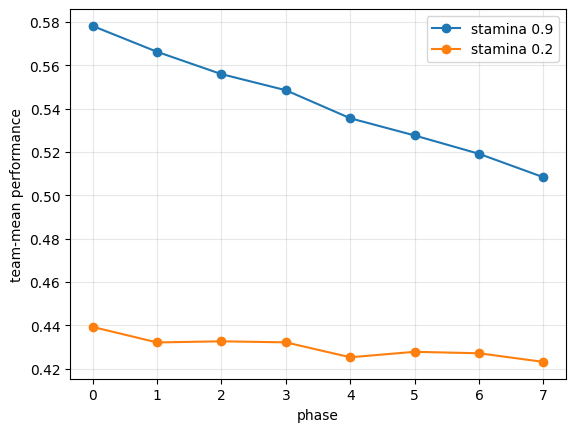

hi-stamina decay: 0.070 (loses more in absolute terms)
lo-stamina decay: 0.016


In [7]:
def roster(stamina):
    return [build_player(f'p{i}', CharacterRole.MIDFIELDER, **{StatName.STAMINA: stamina}) for i in range(4)]

hi = roster(0.9)
lo = roster(0.2)
opp = [build_opponent(f'o{i}', skill=0.5) for i in range(4)]

def sample_performance(players, phase, n=400):
    rng = np.random.default_rng(phase * 100 + 1)
    return np.mean([simulate_phase(players, opp, phase, 0.0, rng).performances.mean() for _ in range(n)])

phases = range(MAX_PHASES_DEFAULT)
hi_line = [sample_performance(hi, p) for p in phases]
lo_line = [sample_performance(lo, p) for p in phases]

plt.plot(phases, hi_line, 'o-', label='stamina 0.9')
plt.plot(phases, lo_line, 'o-', label='stamina 0.2')
plt.xlabel('phase'); plt.ylabel('team-mean performance'); plt.legend(); plt.grid(alpha=0.3); plt.show()

hi_decay = hi_line[0] - hi_line[-1]
lo_decay = lo_line[0] - lo_line[-1]
print(f'hi-stamina decay: {hi_decay:.3f} (loses more in absolute terms)')
print(f'lo-stamina decay: {lo_decay:.3f}')
assert hi_decay > lo_decay, 'high-stamina roster should lose more absolute performance under fatigue'